In [1]:
# Check if GPU is available and set the device accordingly
import torch
import scvi
import scanpy as sc
import os

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using GPU for training.")
else:
    device = torch.device("cpu")
    print("Using CPU for training.")
    scvi.settings.dl_num_workers = 31

/pub/ddlin/projects/sanbomics_scripts/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using CPU for training.


In [2]:
adata = sc.read_csv('data/raw_counts/GSM5226574_C51ctr_raw_counts.csv').T
adata

AnnData object with n_obs × n_vars = 6099 × 34546

In [3]:
adata.X.shape

(6099, 34546)

# Doublet removal - optional but preferred

In [4]:
adata

AnnData object with n_obs × n_vars = 6099 × 34546

In [5]:
sc.pp.filter_genes(adata, min_cells = 10)

In [6]:
sc.pp.highly_variable_genes(adata, n_top_genes = 2000, subset = True, flavor = 'seurat_v3')

In [7]:
scvi.model.SCVI.setup_anndata(adata)
vae = scvi.model.SCVI(adata)
vae.train()

/pub/ddlin/projects/sanbomics_scripts/.venv/lib/python3.13/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /pub/ddlin/projects/sanbomics_scripts/.venv/lib/pyth ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/pub/ddlin/projects/sanbomics_scripts/.venv/lib/python3.13/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /pub/ddlin/projects/sanbomics_scripts/.venv/lib/pyth ...


Epoch 400/400: 100%|██████████| 400/400 [10:43<00:00,  1.51s/it, v_num=1, train_loss_step=303, train_loss_epoch=325]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [10:43<00:00,  1.61s/it, v_num=1, train_loss_step=303, train_loss_epoch=325]


In [8]:
solo = scvi.external.SOLO.from_scvi_model(vae)
solo.train()

INFO     Creating doublets, preparing SOLO model.                                                                  


/pub/ddlin/projects/sanbomics_scripts/.venv/lib/python3.13/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /pub/ddlin/projects/sanbomics_scripts/.venv/lib/pyth ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/pub/ddlin/projects/sanbomics_scripts/.venv/lib/python3.13/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /pub/ddlin/projects/sanbomics_scripts/.venv/lib/pyth ...


Epoch 233/400:  58%|█████▊    | 233/400 [10:23<07:26,  2.68s/it, v_num=1, train_loss_step=0.325, train_loss_epoch=0.293]
Monitored metric validation_loss did not improve in the last 30 records. Best score: 0.267. Signaling Trainer to stop.


In [9]:
df = solo.predict()
df['prediction'] = solo.predict(soft = False)

df.index = df.index.map(lambda x: x[:-2])

df

/pub/ddlin/projects/sanbomics_scripts/.venv/lib/python3.13/site-packages/torch/utils/_contextlib.py:116: UserWarning: Prior to scvi-tools 1.1.3, `SOLO.predict` with `soft=True` (the default option) returned logits instead of probabilities. This behavior has since been corrected to return probabiltiies. The previous behavior can be replicated by passing in `return_logits=True`.
  return func(*args, **kwargs)
/pub/ddlin/projects/sanbomics_scripts/.venv/lib/python3.13/site-packages/torch/utils/_contextlib.py:116: UserWarning: Prior to scvi-tools 1.1.3, `SOLO.predict` with `soft=True` (the default option) returned logits instead of probabilities. This behavior has since been corrected to return probabiltiies. The previous behavior can be replicated by passing in `return_logits=True`.
  return func(*args, **kwargs)


,doublet,singlet,prediction
TAGGTACCATGGCCAC-1,0.837770,0.162230,doublet
ATTCACTGTAACAGGC-1,0.832753,0.167247,doublet
TAACTTCCAACCACGC-1,0.736908,0.263092,doublet
TTGGGTACACGACAAG-1,0.885690,0.114310,doublet
AGGCCACAGAGTCACG-1,0.845711,0.154289,doublet
...,...,...,...
CGCCATTGTTTGCCGG-1,0.539143,0.460857,doublet
CACTGGGGTCTACGTA-1,0.001483,0.998517,singlet
CATACTTGTAGAGGAA-1,0.006220,0.993780,singlet
TTTGGTTTCCACGGAC-1,0.001403,0.998597,singlet


In [10]:
df.groupby('prediction').count()

,doublet,singlet
prediction,,
doublet,1361,1361
singlet,4738,4738


In [11]:
df['dif'] = df.doublet - df.singlet
df

,doublet,singlet,prediction,dif
TAGGTACCATGGCCAC-1,0.837770,0.162230,doublet,0.675539
ATTCACTGTAACAGGC-1,0.832753,0.167247,doublet,0.665505
TAACTTCCAACCACGC-1,0.736908,0.263092,doublet,0.473817
TTGGGTACACGACAAG-1,0.885690,0.114310,doublet,0.771380
AGGCCACAGAGTCACG-1,0.845711,0.154289,doublet,0.691423
...,...,...,...,...
CGCCATTGTTTGCCGG-1,0.539143,0.460857,doublet,0.078287
CACTGGGGTCTACGTA-1,0.001483,0.998517,singlet,-0.997033
CATACTTGTAGAGGAA-1,0.006220,0.993780,singlet,-0.987561
TTTGGTTTCCACGGAC-1,0.001403,0.998597,singlet,-0.997194


In [12]:
import seaborn as sns

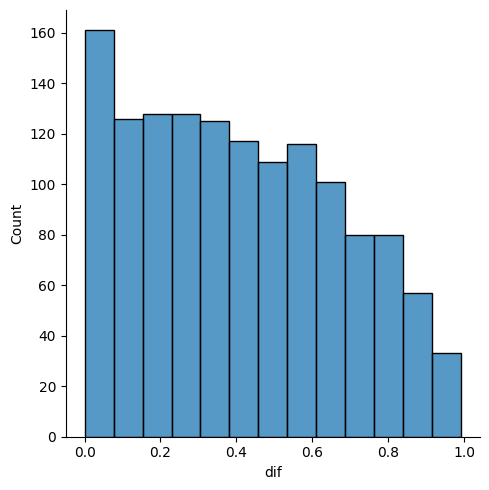

In [13]:
sns.displot(df[df.prediction == 'doublet'], x = 'dif')

In [14]:
doublets = df[(df.prediction == 'doublet') & (df.dif > 1)]
doublets

,doublet,singlet,prediction,dif


In [15]:
adata = sc.read_csv('data/raw_counts/GSM5226574_C51ctr_raw_counts.csv').T

In [16]:
adata.obs['doublet'] = adata.obs.index.isin(doublets.index)

In [17]:
adata.obs

,doublet
TAGGTACCATGGCCAC-1_1,False
ATTCACTGTAACAGGC-1_1,False
TAACTTCCAACCACGC-1_1,False
TTGGGTACACGACAAG-1_1,False
AGGCCACAGAGTCACG-1_1,False
...,...
CGCCATTGTTTGCCGG-1_1,False
CACTGGGGTCTACGTA-1_1,False
CATACTTGTAGAGGAA-1_1,False
TTTGGTTTCCACGGAC-1_1,False


In [18]:
adata = adata[~adata.obs.doublet]

In [19]:
adata

View of AnnData object with n_obs × n_vars = 6099 × 34546
    obs: 'doublet'

# Preprocessing

In [20]:
adata.var['mt'] = adata.var.index.str.startswith('MT-')

/tmp/ipykernel_2793893/310233584.py:1: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var['mt'] = adata.var.index.str.startswith('MT-')


In [21]:
adata.var

,mt
AL627309.1,False
AL627309.5,False
AL627309.4,False
AL669831.2,False
LINC01409,False
...,...
VN1R2,False
AL031676.1,False
SMIM34A,False
AL050402.1,False


In [22]:
import pandas as pd

In [23]:
ribo_url = "http://software.broadinstitute.org/gsea/msigdb/download_geneset.jsp?geneSetName=KEGG_RIBOSOME&fileType=txt"

In [24]:
ribo_genes = pd.read_table(ribo_url, skiprows=2, header = None)
ribo_genes

,0
0,FAU
1,MRPL13
2,RPL10
3,RPL10A
4,RPL10L
...,...
83,RPS9
84,RPSA
85,RSL24D1
86,RSL24D1P11


In [25]:
adata.var['ribo'] = adata.var_names.isin(ribo_genes[0].values)

In [26]:
adata.obs

,doublet
TAGGTACCATGGCCAC-1_1,False
ATTCACTGTAACAGGC-1_1,False
TAACTTCCAACCACGC-1_1,False
TTGGGTACACGACAAG-1_1,False
AGGCCACAGAGTCACG-1_1,False
...,...
CGCCATTGTTTGCCGG-1_1,False
CACTGGGGTCTACGTA-1_1,False
CATACTTGTAGAGGAA-1_1,False
TTTGGTTTCCACGGAC-1_1,False


In [27]:
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt', 'ribo'], percent_top=None, log1p=False, inplace=True)

In [28]:
adata.var.sort_values('n_cells_by_counts')

,mt,ribo,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts
AP003550.1,False,False,0,0.000000,100.000000,0.0
AC105177.1,False,False,0,0.000000,100.000000,0.0
AL353732.1,False,False,0,0.000000,100.000000,0.0
LINC02665,False,False,0,0.000000,100.000000,0.0
AC013799.1,False,False,0,0.000000,100.000000,0.0
...,...,...,...,...,...,...
AKAP13,False,False,4458,3.054271,26.906050,18628.0
NEAT1,False,False,4546,5.314150,25.463191,32411.0
MBNL1,False,False,4554,2.877029,25.332022,17547.0
ZBTB20,False,False,4699,2.601082,22.954583,15864.0


In [29]:
sc.pp.filter_genes(adata, min_cells=3)

In [30]:
adata.var.sort_values('n_cells_by_counts')

,mt,ribo,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,n_cells
OR10G3,False,False,3,0.000492,99.950812,3.0,3
PRKY,False,False,3,0.000492,99.950812,3.0,3
PNCK,False,False,3,0.000492,99.950812,3.0,3
PLXNB3,False,False,3,0.000492,99.950812,3.0,3
AC234781.1,False,False,3,0.000492,99.950812,3.0,3
...,...,...,...,...,...,...,...
AKAP13,False,False,4458,3.054271,26.906050,18628.0,4458
NEAT1,False,False,4546,5.314150,25.463191,32411.0,4546
MBNL1,False,False,4554,2.877029,25.332022,17547.0,4554
ZBTB20,False,False,4699,2.601082,22.954583,15864.0,4699


In [31]:
adata.obs.sort_values('n_genes_by_counts')

,doublet,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo
TAGGGTTTCTGGCTGG-1_1,False,276,419.0,1.0,0.238663,1.0,0.238663
CGTGCTTCAAAGGGCT-1_1,False,277,432.0,41.0,9.490741,0.0,0.000000
TGACAGTTCTAAACGC-1_1,False,278,414.0,0.0,0.000000,0.0,0.000000
CTCTGGTCACGACGAA-1_1,False,285,407.0,0.0,0.000000,0.0,0.000000
GTAAGTCGTATCGCGC-1_1,False,289,430.0,0.0,0.000000,0.0,0.000000
...,...,...,...,...,...,...,...
TAACTTCCAACCACGC-1_1,False,5158,15645.0,221.0,1.412592,211.0,1.348674
CACTGAAGTCGAAGCA-1_1,False,5487,12725.0,355.0,2.789784,82.0,0.644401
AGGCCACAGAGTCACG-1_1,False,5544,13217.0,417.0,3.155028,82.0,0.620413
ATTCACTGTAACAGGC-1_1,False,6686,19020.0,404.0,2.124080,115.0,0.604627


In [32]:
#sc.pp.filter_cells(adata, min_genes=200)

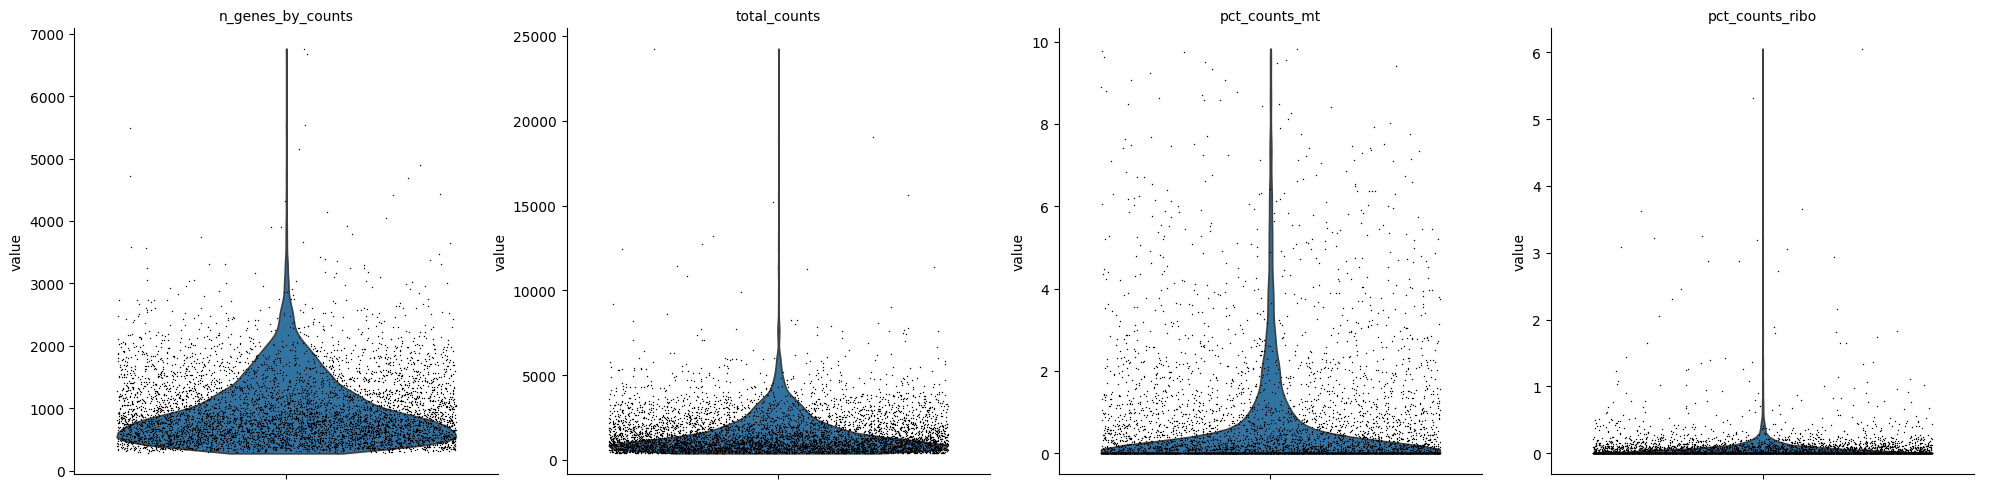

In [33]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo'], 
             jitter=0.4, multi_panel=True)

In [34]:
import numpy as np

In [35]:
upper_lim = np.quantile(adata.obs.n_genes_by_counts.values, .98)
#upper_lim = 3000

In [36]:
upper_lim

np.float64(2479.08)

In [37]:
adata = adata[adata.obs.n_genes_by_counts < upper_lim]

In [38]:
adata.obs

,doublet,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo
CGTTCTGGTACTAGCT-1_1,False,2434,6047.0,6.0,0.099223,1.0,0.016537
CTGGCAGGTTCGGTAT-1_1,False,2444,5899.0,307.0,5.204272,5.0,0.084760
ACACCAACACAACGCC-1_1,False,2451,5497.0,0.0,0.000000,3.0,0.054575
CCTCAACCATACAGGG-1_1,False,2276,5434.0,38.0,0.699301,0.0,0.000000
ACAAAGATCCACAGGC-1_1,False,2310,5504.0,1.0,0.018169,1.0,0.018169
...,...,...,...,...,...,...,...
CGCCATTGTTTGCCGG-1_1,False,355,410.0,3.0,0.731707,0.0,0.000000
CACTGGGGTCTACGTA-1_1,False,346,403.0,0.0,0.000000,0.0,0.000000
CATACTTGTAGAGGAA-1_1,False,360,410.0,2.0,0.487805,0.0,0.000000
TTTGGTTTCCACGGAC-1_1,False,299,405.0,0.0,0.000000,2.0,0.493827


In [39]:
adata = adata[adata.obs.pct_counts_mt < 20]

In [40]:
adata = adata[adata.obs.pct_counts_ribo < 2]

In [41]:
adata

View of AnnData object with n_obs × n_vars = 5960 × 24660
    obs: 'doublet', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'

# Normalization

In [42]:
adata.X.sum(axis = 1)

array([6043., 5895., 5496., ...,  410.,  405.,  410.], dtype=float32)

In [43]:
sc.pp.normalize_total(adata, target_sum=1e4) #normalize every cell to 10,000 UMI

/pub/ddlin/projects/sanbomics_scripts/.venv/lib/python3.13/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [44]:
adata.X.sum(axis = 1)

array([10000., 10000., 10000., ..., 10000., 10000., 10000.], dtype=float32)

In [45]:
sc.pp.log1p(adata) #change to log counts

In [46]:
adata.X.sum(axis = 1)

array([3155.047  , 3218.0122 , 3416.0486 , ..., 1191.2708 , 1022.75116,
       1162.8785 ], dtype=float32)

In [47]:
adata.raw = adata

# Clustering

In [48]:
sc.pp.highly_variable_genes(adata, n_top_genes = 2000)

In [49]:
adata.var

,mt,ribo,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,n_cells,highly_variable,means,dispersions,dispersions_norm
AL627309.1,False,False,8,0.001312,99.868831,8.0,8,False,0.011136,2.697174,1.153160
AL627309.5,False,False,33,0.005411,99.458928,33.0,33,False,0.028855,2.254608,-0.150810
AL627309.4,False,False,4,0.000656,99.934415,4.0,4,False,0.002331,1.702854,-1.776493
LINC01409,False,False,274,0.048697,95.507460,297.0,274,False,0.270478,2.286819,-0.055904
FAM87B,False,False,6,0.000984,99.901623,6.0,6,False,0.006682,1.947490,-1.055700
...,...,...,...,...,...,...,...,...,...,...,...
AL354822.1,False,False,133,0.022627,97.819315,138.0,133,False,0.153974,2.375807,0.206288
AL592183.1,False,False,1003,0.198721,83.554681,1212.0,1003,False,0.875225,2.469386,-0.406744
AC240274.1,False,False,162,0.027382,97.343827,167.0,162,False,0.150268,2.265893,-0.117561
AC007325.4,False,False,4,0.000656,99.934415,4.0,4,False,0.002801,1.579830,-2.138971


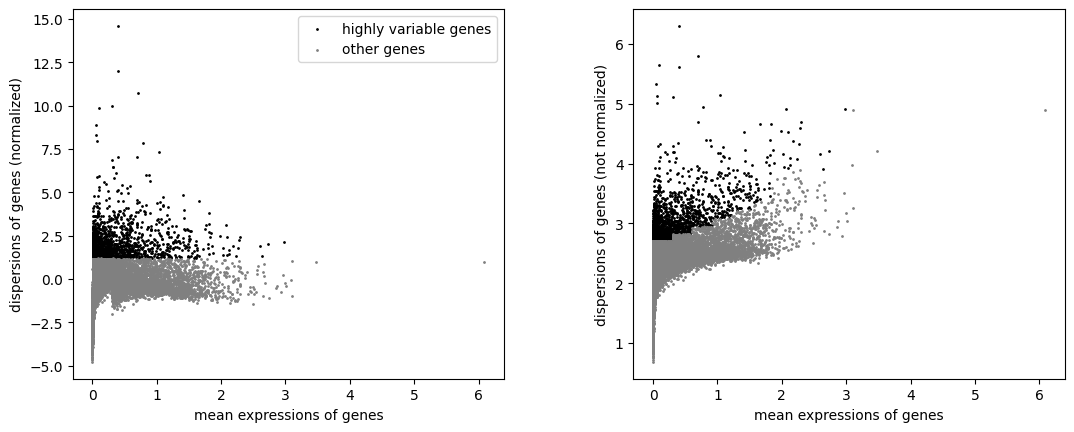

In [50]:
sc.pl.highly_variable_genes(adata)

In [51]:
adata = adata[:, adata.var.highly_variable]

In [52]:
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt', 'pct_counts_ribo'])

/pub/ddlin/projects/sanbomics_scripts/.venv/lib/python3.13/site-packages/scanpy/preprocessing/_simple.py:729: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/pub/ddlin/projects/sanbomics_scripts/.venv/lib/python3.13/site-packages/scanpy/preprocessing/_simple.py:667: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff
/pub/ddlin/projects/sanbomics_scripts/.venv/lib/python3.13/site-packages/scanpy/preprocessing/_simple.py:667: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff


In [53]:
sc.pp.scale(adata, max_value=10)

In [54]:
sc.tl.pca(adata, svd_solver='arpack')

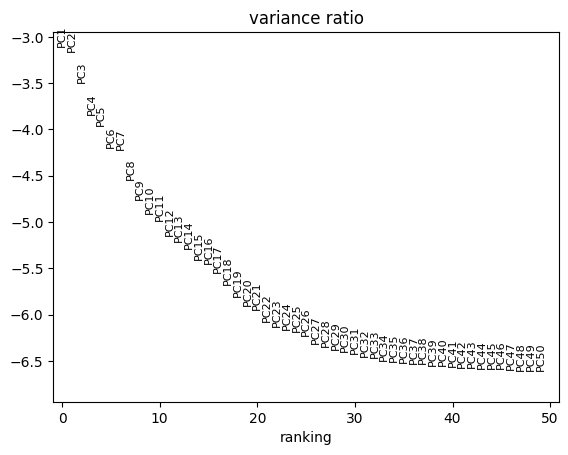

In [55]:
sc.pl.pca_variance_ratio(adata, log=True, n_pcs = 50)

In [56]:
sc.pp.neighbors(adata, n_pcs = 30)

In [57]:
sc.tl.umap(adata)

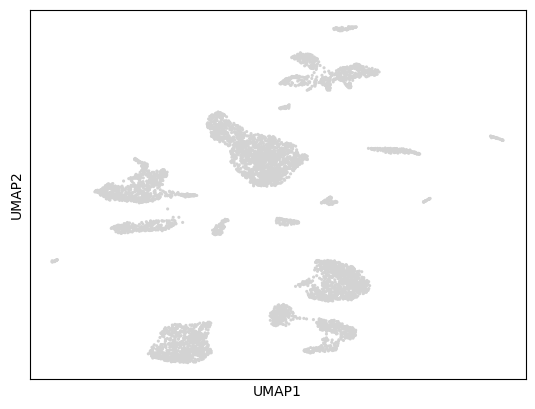

In [58]:
sc.pl.umap(adata)

In [59]:
sc.tl.leiden(adata, resolution = 0.5)

/tmp/ipykernel_2793893/3246266323.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution = 0.5)


In [60]:
adata.obs

,doublet,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,leiden
CGTTCTGGTACTAGCT-1_1,False,2434,6047.0,6.0,0.099223,1.0,0.016537,2
CTGGCAGGTTCGGTAT-1_1,False,2444,5899.0,307.0,5.204272,5.0,0.084760,2
ACACCAACACAACGCC-1_1,False,2451,5497.0,0.0,0.000000,3.0,0.054575,1
CCTCAACCATACAGGG-1_1,False,2276,5434.0,38.0,0.699301,0.0,0.000000,11
ACAAAGATCCACAGGC-1_1,False,2310,5504.0,1.0,0.018169,1.0,0.018169,2
...,...,...,...,...,...,...,...,...
CGCCATTGTTTGCCGG-1_1,False,355,410.0,3.0,0.731707,0.0,0.000000,6
CACTGGGGTCTACGTA-1_1,False,346,403.0,0.0,0.000000,0.0,0.000000,1
CATACTTGTAGAGGAA-1_1,False,360,410.0,2.0,0.487805,0.0,0.000000,0
TTTGGTTTCCACGGAC-1_1,False,299,405.0,0.0,0.000000,2.0,0.493827,12


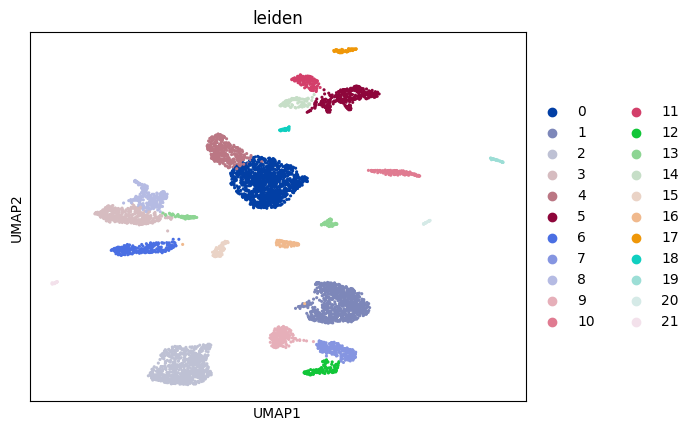

In [61]:
sc.pl.umap(adata, color=['leiden'])

# Integration

In [62]:
def pp(csv_path):
    adata = sc.read_csv(csv_path).T
    sc.pp.filter_genes(adata, min_cells = 10)
    sc.pp.highly_variable_genes(adata, n_top_genes = 2000, subset = True, flavor = 'seurat_v3')
    scvi.model.SCVI.setup_anndata(adata)
    vae = scvi.model.SCVI(adata)
    vae.train()
    solo = scvi.external.SOLO.from_scvi_model(vae)
    solo.train()
    df = solo.predict()
    df['prediction'] = solo.predict(soft = False)
    df.index = df.index.map(lambda x: x[:-2])
    df['dif'] = df.doublet - df.singlet
    doublets = df[(df.prediction == 'doublet') & (df.dif > 1)]
    
    adata = sc.read_csv(csv_path).T
    adata.obs['Sample'] = csv_path.split('_')[2] #'raw_counts/GSM5226574_C51ctr_raw_counts.csv'
    
    adata.obs['doublet'] = adata.obs.index.isin(doublets.index)
    adata = adata[~adata.obs.doublet]
    
    
    sc.pp.filter_cells(adata, min_genes=200) #get rid of cells with fewer than 200 genes
    #sc.pp.filter_genes(adata, min_cells=3) #get rid of genes that are found in fewer than 3 cells
    adata.var['mt'] = adata.var_names.str.startswith('mt-')  # annotate the group of mitochondrial genes as 'mt'
    adata.var['ribo'] = adata.var_names.isin(ribo_genes[0].values)
    sc.pp.calculate_qc_metrics(adata, qc_vars=['mt', 'ribo'], percent_top=None, log1p=False, inplace=True)
    upper_lim = np.quantile(adata.obs.n_genes_by_counts.values, .98)
    adata = adata[adata.obs.n_genes_by_counts < upper_lim]
    adata = adata[adata.obs.pct_counts_mt < 20]
    adata = adata[adata.obs.pct_counts_ribo < 2]

    return adata

In [63]:
import os

In [64]:
out = []
for file in os.listdir('data/raw_counts/'):
    out.append(pp('data/raw_counts/' + file))

/pub/ddlin/projects/sanbomics_scripts/.venv/lib/python3.13/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /pub/ddlin/projects/sanbomics_scripts/.venv/lib/pyth ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/pub/ddlin/projects/sanbomics_scripts/.venv/lib/python3.13/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /pub/ddlin/projects/sanbomics_scripts/.venv/lib/pyth ...


Epoch 400/400: 100%|██████████| 400/400 [10:52<00:00,  1.61s/it, v_num=1, train_loss_step=322, train_loss_epoch=325]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [10:52<00:00,  1.63s/it, v_num=1, train_loss_step=322, train_loss_epoch=325]
INFO     Creating doublets, preparing SOLO model.                                                                  


/pub/ddlin/projects/sanbomics_scripts/.venv/lib/python3.13/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /pub/ddlin/projects/sanbomics_scripts/.venv/lib/pyth ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/pub/ddlin/projects/sanbomics_scripts/.venv/lib/python3.13/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /pub/ddlin/projects/sanbomics_scripts/.venv/lib/pyth ...


...

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [17:13<00:00,  2.58s/it, v_num=1, train_loss_step=347, train_loss_epoch=341]
INFO     Creating doublets, preparing SOLO model.                                                                  


/pub/ddlin/projects/sanbomics_scripts/.venv/lib/python3.13/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /pub/ddlin/projects/sanbomics_scripts/.venv/lib/pyth ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/pub/ddlin/projects/sanbomics_scripts/.venv/lib/python3.13/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /pub/ddlin/projects/sanbomics_scripts/.venv/lib/pyth ...


Epoch 201/400:  50%|█████     | 201/400 [15:01<14:52,  4.48s/it, v_num=1, train_loss_step=0.379, train_loss_epoch=0.312]
Monitored metric validation_loss did not improve in the last 30 records. Best score: 0.306. Signaling Trainer to stop.


/pub/ddlin/projects/sanbomics_scripts/.venv/lib/python3.13/site-packages/torch/utils/_contextlib.py:116: UserWarning: Prior to scvi-tools 1.1.3, `SOLO.predict` with `soft=True` (the default option) returned logits instead of probabilities. This behavior has since been corrected to return probabiltiies. The previous behavior can be replicated by passing in `return_logits=True`.
  return func(*args, **kwargs)
/pub/ddlin/projects/sanbomics_scripts/.venv/lib/python3.13/site-packages/torch/utils/_contextlib.py:116: UserWarning: Prior to scvi-tools 1.1.3, `SOLO.predict` with `soft=True` (the default option) returned logits instead of probabilities. This behavior has since been corrected to return probabiltiies. The previous behavior can be replicated by passing in `return_logits=True`.
  return func(*args, **kwargs)
/pub/ddlin/projects/sanbomics_scripts/.venv/lib/python3.13/site-packages/scanpy/preprocessing/_simple.py:176: ImplicitModificationWarning: Trying to modify attribute `.obs` of vi

In [65]:
adata = sc.concat(out)

In [66]:
adata

AnnData object with n_obs × n_vars = 108822 × 34546
    obs: 'Sample', 'doublet', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo'

In [67]:
sc.pp.filter_genes(adata, min_cells = 10)

In [68]:
adata.X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [69]:
from scipy.sparse import csr_matrix

In [70]:
adata.X = csr_matrix(adata.X)

In [71]:
adata.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 95760461 stored elements and shape (108822, 29581)>

In [72]:
adata.write_h5ad('combined.h5ad')

In [73]:
########################################################

In [74]:
import scanpy as sc
import scvi
import seaborn as sns
import numpy as np
import pandas as pd

In [75]:
adata = sc.read_h5ad('combined.h5ad')
adata

AnnData object with n_obs × n_vars = 108822 × 29581
    obs: 'Sample', 'doublet', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo'
    var: 'n_cells'

In [76]:
adata.obs.groupby('Sample').count()

/tmp/ipykernel_2793893/2340059915.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby('Sample').count()


,doublet,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo
Sample,,,,,,,,
C51ctr,5960,5960,5960,5960,5960,5960,5960,5960
C52ctr,4415,4415,4415,4415,4415,4415,4415,4415
C53ctr,6928,6928,6928,6928,6928,6928,6928,6928
C54ctr,4284,4284,4284,4284,4284,4284,4284,4284
C55ctr,5565,5565,5565,5565,5565,5565,5565,5565
C56ctr,3904,3904,3904,3904,3904,3904,3904,3904
C57ctr,4687,4687,4687,4687,4687,4687,4687,4687
L01cov,2952,2952,2952,2952,2952,2952,2952,2952
L03cov,3953,3953,3953,3953,3953,3953,3953,3953


In [77]:
sc.pp.filter_genes(adata, min_cells = 100)

In [78]:
adata

AnnData object with n_obs × n_vars = 108822 × 21306
    obs: 'Sample', 'doublet', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo'
    var: 'n_cells'

In [79]:
adata.layers['counts'] = adata.X.copy()

In [80]:
sc.pp.normalize_total(adata, target_sum = 1e4)
sc.pp.log1p(adata)
adata.raw = adata

In [81]:
adata.obs.head()

,Sample,doublet,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo
CGTTCTGGTACTAGCT-1_1,C51ctr,False,2434,2434,6047.0,0.0,0.0,1.0,0.016537
CTGGCAGGTTCGGTAT-1_1,C51ctr,False,2444,2444,5899.0,0.0,0.0,5.0,0.084760
ACACCAACACAACGCC-1_1,C51ctr,False,2451,2451,5497.0,0.0,0.0,3.0,0.054575
CCTCAACCATACAGGG-1_1,C51ctr,False,2276,2276,5434.0,0.0,0.0,0.0,0.000000
ACAAAGATCCACAGGC-1_1,C51ctr,False,2310,2310,5504.0,0.0,0.0,1.0,0.018169


In [82]:
adata

AnnData object with n_obs × n_vars = 108822 × 21306
    obs: 'Sample', 'doublet', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo'
    var: 'n_cells'
    uns: 'log1p'
    layers: 'counts'

In [83]:
# sc.pp.highly_variable_genes(adata, n_top_genes=3000, subset = True, layer = 'counts',
#                            flavor = "seurat_v3", batch_key="Sample") #no batch_key if one sample

In [84]:
scvi.model.SCVI.setup_anndata(adata, layer = "counts",
                             categorical_covariate_keys=["Sample"],
                             continuous_covariate_keys=['pct_counts_mt', 'total_counts', 'pct_counts_ribo'])

In [85]:
model = scvi.model.SCVI(adata)

In [86]:
model.train() #may take a while without GPU

/pub/ddlin/projects/sanbomics_scripts/.venv/lib/python3.13/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /pub/ddlin/projects/sanbomics_scripts/.venv/lib/pyth ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/pub/ddlin/projects/sanbomics_scripts/.venv/lib/python3.13/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /pub/ddlin/projects/sanbomics_scripts/.venv/lib/pyth ...


Epoch 74/74: 100%|██████████| 74/74 [1:03:55<00:00, 53.66s/it, v_num=1, train_loss_step=2.87e+3, train_loss_epoch=2.94e+3]

`Trainer.fit` stopped: `max_epochs=74` reached.


Epoch 74/74: 100%|██████████| 74/74 [1:03:55<00:00, 51.82s/it, v_num=1, train_loss_step=2.87e+3, train_loss_epoch=2.94e+3]


In [87]:
adata.obsm['X_scVI'] = model.get_latent_representation()

In [88]:
adata.layers['scvi_normalized'] = model.get_normalized_expression(library_size = 1e4)

In [89]:
sc.pp.neighbors(adata, use_rep = 'X_scVI')

In [90]:
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution = 0.5)

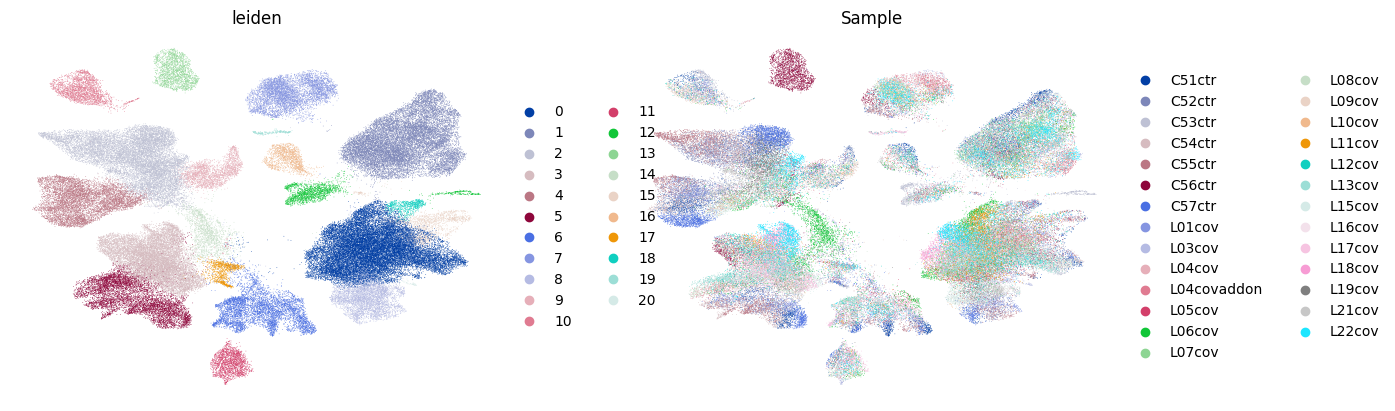

In [91]:
sc.pl.umap(adata, color = ['leiden', 'Sample'], frameon = False)

In [92]:
adata.write_h5ad('integrated.h5ad')

# Find markers/ label cell types

In [93]:
sc.tl.leiden(adata, resolution = 1)

In [94]:
sc.tl.rank_genes_groups(adata, 'leiden')

/pub/ddlin/projects/sanbomics_scripts/.venv/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:456: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/pub/ddlin/projects/sanbomics_scripts/.venv/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/pub/ddlin/projects/sanbomics_scripts/.venv/lib/python3.13/site-packages/scanpy/tools/_rank_g

In [95]:
#sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)

In [96]:
markers = sc.get.rank_genes_groups_df(adata, None)
markers = markers[(markers.pvals_adj < 0.05) & (markers.logfoldchanges > .5)]
markers

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,CTSB,160.632568,4.888740,0.000000,0.000000
1,0,PSAP,150.386276,5.060416,0.000000,0.000000
2,0,CTSD,135.343353,5.809619,0.000000,0.000000
3,0,FMN1,119.990166,3.418059,0.000000,0.000000
4,0,FTL,118.883331,5.011919,0.000000,0.000000
...,...,...,...,...,...,...
554662,26,EEF1G,2.130524,2.717924,0.038628,0.049149
554663,26,NDUFA2,2.126411,4.566134,0.038988,0.049601
554664,26,ADCK2,2.126212,4.091731,0.039005,0.049621
554665,26,PLEK,2.123705,2.321306,0.039225,0.049891


In [97]:
markers_scvi = model.differential_expression(groupby = 'leiden')
markers_scvi

DE...: 100%|██████████| 27/27 [27:48<00:00, 61.80s/it]


,proba_m1,proba_m2,bayes_factor,scale1,scale2,raw_mean1,raw_mean2,non_zeros_proportion1,non_zeros_proportion2,raw_normalized_mean1,raw_normalized_mean2,comparison,group1,group2
MGAT1,0.9792,0.0208,3.851782,0.000636,0.000089,0.946882,0.094206,0.466398,0.068189,5.434004,0.682727,0 vs Rest,0,Rest
UAP1L1,0.9708,0.0292,3.503951,0.000031,0.000008,0.062398,0.010394,0.057506,0.010054,0.336786,0.075020,0 vs Rest,0,Rest
H2AFY,0.9696,0.0304,3.462441,0.000659,0.000126,1.185749,0.153325,0.562269,0.103868,7.202292,1.056659,0 vs Rest,0,Rest
SPP1,0.9694,0.0306,3.455677,0.000651,0.000031,1.478080,0.051899,0.224187,0.011485,7.715400,0.317917,0 vs Rest,0,Rest
CTSD,0.9692,0.0308,3.448956,0.002636,0.000130,5.551172,0.192997,0.692387,0.056704,27.933685,1.088608,0 vs Rest,0,Rest
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LRCH3,0.0000,1.0000,-18.420681,0.000053,0.000170,0.000000,0.234105,0.000000,0.190088,0.000000,1.840043,26 vs Rest,26,Rest
DDX17,0.0000,1.0000,-18.420681,0.000142,0.000585,0.065217,0.740738,0.043478,0.465222,0.398909,5.876076,26 vs Rest,26,Rest
ZFAT,0.0000,1.0000,-18.420681,0.000009,0.000055,0.000000,0.081806,0.000000,0.067533,0.000000,0.648247,26 vs Rest,26,Rest
ADNP,0.0000,1.0000,-18.420681,0.000050,0.000196,0.065217,0.238444,0.065217,0.191559,0.718795,1.840407,26 vs Rest,26,Rest


In [99]:
markers_scvi = model.differential_expression(
    groupby='leiden',
    mode='change',      # Ensures Bayesian DE with Bayes factors, probabilities, etc.
    fdr_target=0.05     # Adds 'is_de_fdr_0.05' for FDR-controlled DE tagging
)

DE...: 100%|██████████| 27/27 [29:58<00:00, 66.60s/it]


In [100]:
# Check the shape
print(f'markers_scvi shape before filtering: {markers_scvi.shape}')

# Filter for significant DE genes
markers_scvi = markers_scvi[(markers_scvi['is_de_fdr_0.05']) & (markers_scvi['lfc_mean'] > 0.5)]
print(f'markers_scvi shape after filtering: {markers_scvi.shape}')

markers_scvi

markers_scvi shape before filtering: (575262, 22)
markers_scvi shape after filtering: (3750, 22)


,proba_de,proba_not_de,bayes_factor,scale1,scale2,pseudocounts,delta,lfc_mean,lfc_median,lfc_std,...,raw_mean1,raw_mean2,non_zeros_proportion1,non_zeros_proportion2,raw_normalized_mean1,raw_normalized_mean2,is_de_fdr_0.05,comparison,group1,group2
CTSD,0.9584,0.0416,3.137165,0.002607,0.000150,0.000242,0.25,6.427063,6.807249,3.209599,...,5.551172,0.192997,0.692387,0.056704,27.933685,1.088608,True,0 vs Rest,0,Rest
MGAT1,0.9508,0.0492,2.961410,0.000636,0.000093,0.000242,0.25,3.913615,4.185853,1.944538,...,0.946882,0.094206,0.466398,0.068189,5.434004,0.682727,True,0 vs Rest,0,Rest
CTSB,0.9462,0.0538,2.867180,0.001861,0.000209,0.000242,0.25,5.106693,5.467506,2.703724,...,4.796979,0.353226,0.791091,0.122866,24.843254,2.430781,True,0 vs Rest,0,Rest
CAMK4,0.9924,0.0076,4.871977,0.001498,0.000055,0.000250,0.25,6.480377,6.671234,2.147743,...,1.018368,0.030482,0.524678,0.017177,14.289256,0.257916,True,1 vs Rest,1,Rest
NCK2,0.9898,0.0102,4.575114,0.000794,0.000099,0.000250,0.25,3.257153,3.346334,1.065664,...,0.524684,0.115146,0.366664,0.095053,7.174355,0.892624,True,1 vs Rest,1,Rest
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CD37,0.8592,0.1408,1.808661,0.000126,0.000034,0.000257,0.25,2.403441,2.205416,1.374702,...,0.086957,0.038622,0.086957,0.034943,0.822864,0.301944,True,26 vs Rest,26,Rest
HTATIP2,0.8590,0.1410,1.807009,0.000083,0.000012,0.000257,0.25,3.270854,3.231112,1.294661,...,0.130435,0.016640,0.130435,0.015803,1.900461,0.107327,True,26 vs Rest,26,Rest
RPL15,0.8588,0.1412,1.805359,0.000219,0.000037,0.000257,0.25,3.539411,3.771794,1.910145,...,0.260870,0.043081,0.217391,0.034714,2.762637,0.236649,True,26 vs Rest,26,Rest
AKR1B1,0.8586,0.1414,1.803710,0.000122,0.000016,0.000257,0.25,3.839419,3.783777,1.890740,...,0.108696,0.020611,0.108696,0.018699,1.657043,0.143846,True,26 vs Rest,26,Rest


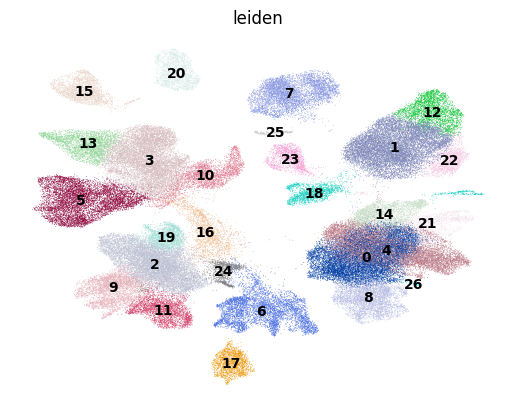

In [101]:
sc.pl.umap(adata, color = ['leiden'], frameon = False, legend_loc = "on data")

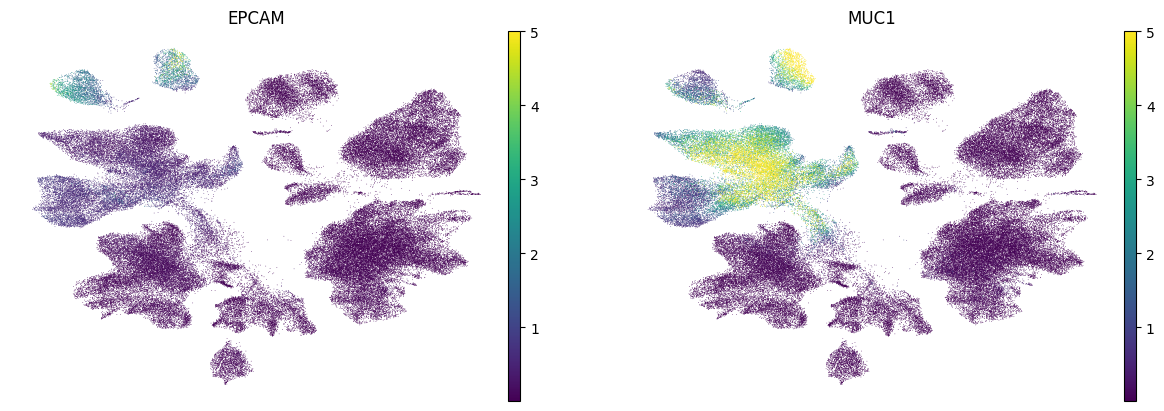

In [102]:
sc.pl.umap(adata, color = ['EPCAM', 'MUC1'], frameon = False, layer = 'scvi_normalized', vmax = 5)
#, layer = 'scvi_normalized'

In [103]:
cell_type = {"0":"Macrophage",
"1":"Fibroblast",
"2":"CD4+ T-cell",
"3":"AT2",
"4":"AT1",
"5":"CD8+ T-cell",
"6":"Endothelial cell",
"7":"Plasma cell",
"8":"Macrophage",
"9":"AT2",
"10":"Fibroblast",
"11":"Fibroblast",
"12":"Macrophage",
"13":"Macrophage",
"14":"Airway epithelial",
"15":"Airway epithelial",
"16":"Monocyte",
"17":"Airway epithelial",
"18":"B-cell",
"19":"Aerocyte",
"20":"Airway epithelial",
"21":"Smooth muscle cell",
"22":"Cycling T/NK",
"23":"Neuronal cell",
"24":"Denditic cell",
"25":"Pericyte",
"26":"Fibroblast",
"27":"Erythroid-like",
"28":"Macrophage"
}


In [104]:
adata.obs['cell type'] = adata.obs.leiden.map(cell_type)

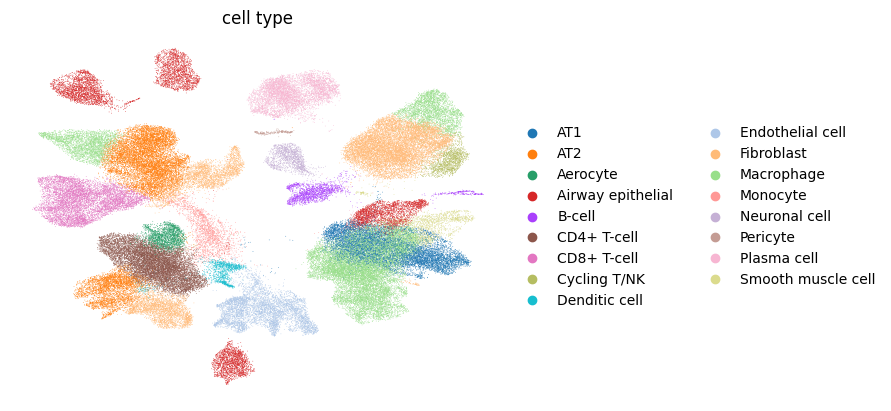

In [105]:
sc.pl.umap(adata, color = ['cell type'], frameon = False)

In [106]:
adata

AnnData object with n_obs × n_vars = 108822 × 21306
    obs: 'Sample', 'doublet', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', '_scvi_batch', '_scvi_labels', 'leiden', '_scvi_raw_norm_scaling', 'cell type'
    var: 'n_cells'
    uns: 'log1p', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'Sample_colors', 'rank_genes_groups', 'cell type_colors'
    obsm: '_scvi_extra_categorical_covs', '_scvi_extra_continuous_covs', 'X_scVI', 'X_umap'
    layers: 'counts', 'scvi_normalized'
    obsp: 'distances', 'connectivities'

In [107]:
adata.uns['scvi_markers'] = markers_scvi
adata.uns['markers'] = markers

In [108]:
adata.write_h5ad('integrated.h5ad')

In [109]:
model.save('model.model')

# Analysis

In [110]:
import scanpy as sc
import scvi
import seaborn as sns
import numpy as np
import pandas as pd

## Counting cells

In [111]:
adata = sc.read_h5ad('integrated.h5ad')

In [112]:
adata.obs.Sample.unique().tolist()

['C51ctr',
 'C52ctr',
 'C53ctr',
 'C54ctr',
 'C55ctr',
 'C56ctr',
 'C57ctr',
 'L01cov',
 'L03cov',
 'L04cov',
 'L04covaddon',
 'L05cov',
 'L06cov',
 'L07cov',
 'L08cov',
 'L09cov',
 'L10cov',
 'L11cov',
 'L12cov',
 'L13cov',
 'L15cov',
 'L16cov',
 'L17cov',
 'L18cov',
 'L19cov',
 'L21cov',
 'L22cov']

In [113]:
def map_condition(x):
    if 'cov' in x:
        return 'COVID19'
    else:
        return 'control'

In [114]:
adata.obs['condition'] = adata.obs.Sample.map(map_condition)
adata.obs

,Sample,doublet,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,_scvi_batch,_scvi_labels,leiden,_scvi_raw_norm_scaling,cell type,condition
CGTTCTGGTACTAGCT-1_1,C51ctr,False,2434,2434,6047.0,0.0,0.0,1.0,0.016537,0,0,3,1.656726,AT2,control
CTGGCAGGTTCGGTAT-1_1,C51ctr,False,2444,2444,5899.0,0.0,0.0,5.0,0.084760,0,0,3,1.699524,AT2,control
ACACCAACACAACGCC-1_1,C51ctr,False,2451,2451,5497.0,0.0,0.0,3.0,0.054575,0,0,5,1.821494,CD8+ T-cell,control
CCTCAACCATACAGGG-1_1,C51ctr,False,2276,2276,5434.0,0.0,0.0,0.0,0.000000,0,0,8,1.842978,Macrophage,control
ACAAAGATCCACAGGC-1_1,C51ctr,False,2310,2310,5504.0,0.0,0.0,1.0,0.018169,0,0,3,1.819174,AT2,control
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CCTAAGAAGTTGTCAC-1_27,L22cov,False,344,344,413.0,0.0,0.0,0.0,0.000000,0,0,16,24.213076,Monocyte,COVID19
CGTGAATCATGTCTAG-1_27,L22cov,False,350,350,402.0,0.0,0.0,0.0,0.000000,0,0,4,24.937656,AT1,COVID19
GCCGATGAGTAAACGT-1_27,L22cov,False,326,326,401.0,0.0,0.0,8.0,1.995013,0,0,3,24.937656,AT2,COVID19
AGGGTGAGTATCAGGG-1_27,L22cov,False,331,331,402.0,0.0,0.0,0.0,0.000000,0,0,3,24.937656,AT2,COVID19


In [115]:
num_tot_cells = adata.obs.groupby(['Sample']).count()
num_tot_cells = dict(zip(num_tot_cells.index, num_tot_cells.doublet))
num_tot_cells

/tmp/ipykernel_2793893/2419454245.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  num_tot_cells = adata.obs.groupby(['Sample']).count()


{'C51ctr': 5960,
 'C52ctr': 4415,
 'C53ctr': 6928,
 'C54ctr': 4284,
 'C55ctr': 5565,
 'C56ctr': 3904,
 'C57ctr': 4687,
 'L01cov': 2952,
 'L03cov': 3953,
 'L04cov': 3401,
 'L04covaddon': 4386,
 'L05cov': 2696,
 'L06cov': 6306,
 'L07cov': 4753,
 'L08cov': 3767,
 'L09cov': 3368,
 'L10cov': 1501,
 'L11cov': 2888,
 'L12cov': 3648,
 'L13cov': 4732,
 'L15cov': 3905,
 'L16cov': 1773,
 'L17cov': 4341,
 'L18cov': 2633,
 'L19cov': 2429,
 'L21cov': 3257,
 'L22cov': 6390}

In [116]:
cell_type_counts = adata.obs.groupby(['Sample', 'condition', 'cell type']).count()
cell_type_counts = cell_type_counts[cell_type_counts.sum(axis = 1) > 0].reset_index()
cell_type_counts = cell_type_counts[cell_type_counts.columns[0:4]]
cell_type_counts

/tmp/ipykernel_2793893/2058450824.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_type_counts = adata.obs.groupby(['Sample', 'condition', 'cell type']).count()


,Sample,condition,cell type,doublet
0,C51ctr,control,AT1,269
1,C51ctr,control,AT2,944
2,C51ctr,control,Airway epithelial,395
3,C51ctr,control,B-cell,39
4,C51ctr,control,CD4+ T-cell,16
...,...,...,...,...
423,L22cov,COVID19,Monocyte,23
424,L22cov,COVID19,Neuronal cell,8
425,L22cov,COVID19,Pericyte,10
426,L22cov,COVID19,Plasma cell,540


In [117]:
cell_type_counts['total_cells'] = cell_type_counts.Sample.map(num_tot_cells).astype(int)

cell_type_counts['frequency'] = cell_type_counts.doublet / cell_type_counts.total_cells

cell_type_counts

,Sample,condition,cell type,doublet,total_cells,frequency
0,C51ctr,control,AT1,269,5960,0.045134
1,C51ctr,control,AT2,944,5960,0.158389
2,C51ctr,control,Airway epithelial,395,5960,0.066275
3,C51ctr,control,B-cell,39,5960,0.006544
4,C51ctr,control,CD4+ T-cell,16,5960,0.002685
...,...,...,...,...,...,...
423,L22cov,COVID19,Monocyte,23,6390,0.003599
424,L22cov,COVID19,Neuronal cell,8,6390,0.001252
425,L22cov,COVID19,Pericyte,10,6390,0.001565
426,L22cov,COVID19,Plasma cell,540,6390,0.084507


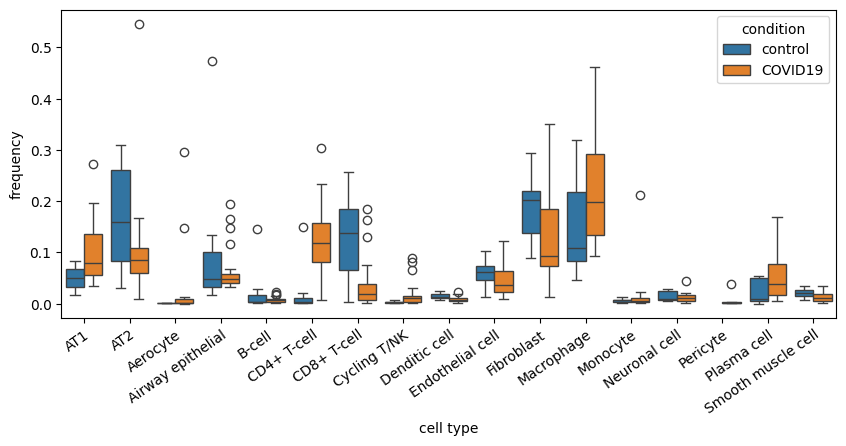

In [118]:
import matplotlib.pyplot as plt

plt.figure(figsize = (10,4))

ax = sns.boxplot(data = cell_type_counts, x = 'cell type', y = 'frequency', hue = 'condition')

plt.xticks(rotation = 35, rotation_mode = 'anchor', ha = 'right')

plt.show()


## DE

In [119]:
subset = adata[adata.obs['cell type'].isin(['AT1', 'AT2'])].copy()

In [120]:
#two options: SCVI or diffxpy

In [122]:
import diffxpy.api as de

In [123]:
subset.X = subset.X.toarray()

In [124]:
len(subset.var)

21306

In [125]:
subset

AnnData object with n_obs × n_vars = 21950 × 21306
    obs: 'Sample', 'doublet', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', '_scvi_batch', '_scvi_labels', 'leiden', '_scvi_raw_norm_scaling', 'cell type', 'condition'
    var: 'n_cells'
    uns: 'Sample_colors', '_scvi_manager_uuid', '_scvi_uuid', 'cell type_colors', 'leiden', 'leiden_colors', 'log1p', 'markers', 'neighbors', 'rank_genes_groups', 'scvi_markers', 'umap'
    obsm: 'X_scVI', 'X_umap', '_scvi_extra_categorical_covs', '_scvi_extra_continuous_covs'
    layers: 'counts', 'scvi_normalized'
    obsp: 'connectivities', 'distances'

In [134]:
sc.pp.filter_genes(subset, min_cells=100)
sc.pp.filter_genes(subset, min_counts=20)

In [135]:
len(subset.var)

14474

In [136]:
subset.obs = subset.obs.rename(columns = {'cell type':'cell_type'})

In [137]:
#subset = subset.raw.to_adata() #need to run this if you scaled/regress your data and have negative numbers


In [138]:
subset.obs

,Sample,doublet,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,_scvi_batch,_scvi_labels,leiden,_scvi_raw_norm_scaling,cell_type,condition
CGTTCTGGTACTAGCT-1_1,C51ctr,False,2434,2434,6047.0,0.0,0.0,1.0,0.016537,0,0,3,1.656726,AT2,control
CTGGCAGGTTCGGTAT-1_1,C51ctr,False,2444,2444,5899.0,0.0,0.0,5.0,0.084760,0,0,3,1.699524,AT2,control
ACAAAGATCCACAGGC-1_1,C51ctr,False,2310,2310,5504.0,0.0,0.0,1.0,0.018169,0,0,3,1.819174,AT2,control
ATACTTCCAAGGTCTT-1_1,C51ctr,False,2122,2122,5252.0,0.0,0.0,4.0,0.076161,0,0,3,1.905488,AT2,control
CAGGGCTGTGCACAAG-1_1,C51ctr,False,2323,2323,5187.0,0.0,0.0,1.0,0.019279,0,0,3,1.931621,AT2,control
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGTGGATCATAGGCT-1_27,L22cov,False,329,329,406.0,0.0,0.0,1.0,0.246305,0,0,3,24.691359,AT2,COVID19
CGTGAATCATGTCTAG-1_27,L22cov,False,350,350,402.0,0.0,0.0,0.0,0.000000,0,0,4,24.937656,AT1,COVID19
GCCGATGAGTAAACGT-1_27,L22cov,False,326,326,401.0,0.0,0.0,8.0,1.995013,0,0,3,24.937656,AT2,COVID19
AGGGTGAGTATCAGGG-1_27,L22cov,False,331,331,402.0,0.0,0.0,0.0,0.000000,0,0,3,24.937656,AT2,COVID19


In [139]:
import patsy
dmat = patsy.dmatrix('~ 1 + cell_type', subset.obs)
print(dmat.design_info.column_names)  # Outputs: ['Intercept', 'cell_type[T.AT2]']

['Intercept', 'cell_type[T.AT2]']


In [141]:
#if want to test between covid/non covid
# res = de.test.wald(data=subset,
#              formula_loc= '~ 1 + condition',
#              factor_loc_totest='condition'
#                   )

res = de.test.wald(
    data=subset,
    formula_loc='~ 1 + cell_type',
    factor_loc_totest='cell_type[T.AT2]',
    batch_size=(1024, 1024)  # Example: 512 cells and 512 genes per chunk; adjust based on memory
)

training location model: False
training scale model: True


/pub/ddlin/projects/sanbomics_scripts/.venv/lib/python3.13/site-packages/dask/array/routines.py:452: PerformanceWarning: Increasing number of chunks by factor of 15
  out = blockwise(
/pub/ddlin/projects/sanbomics_scripts/.venv/lib/python3.13/site-packages/dask/array/routines.py:452: PerformanceWarning: Increasing number of chunks by factor of 15
  out = blockwise(
/pub/ddlin/projects/sanbomics_scripts/.venv/lib/python3.13/site-packages/dask/tokenize.py:240: UserWarning: Torchaudio's I/O functions now support par-call bakcend dispatch. Importing backend implementation directly is no longer guaranteed to work. Please use `backend` keyword with load/save/info function, instead of calling the udnerlying implementation directly.
  out = pickle.dumps(o, protocol=5, buffer_callback=buffers.append)
/pub/ddlin/projects/sanbomics_scripts/.venv/lib/python3.13/site-packages/dask/tokenize.py:240: UserWarning: Torchaudio's I/O functions now support par-call bakcend dispatch. Importing backend imple

iter   0: ll=196308626.658226
iter   1: ll=196308626.658226, converged: 0.00% (loc: 100.00%, scale update: False), in 0.00sec
Fitting 14474 dispersion models: (progress not available with multiprocessing)

/pub/ddlin/projects/sanbomics_scripts/.venv/lib/python3.13/site-packages/dask/array/routines.py:452: PerformanceWarning: Increasing number of chunks by factor of 15
  out = blockwise(


/pub/ddlin/projects/sanbomics_scripts/.venv/lib/python3.13/site-packages/dask/array/routines.py:452: PerformanceWarning: Increasing number of chunks by factor of 15
  out = blockwise(
/pub/ddlin/projects/sanbomics_scripts/.venv/lib/python3.13/site-packages/dask/array/routines.py:452: PerformanceWarning: Increasing number of chunks by factor of 15
  out = blockwise(
/pub/ddlin/projects/sanbomics_scripts/.venv/lib/python3.13/site-packages/dask/tokenize.py:240: UserWarning: Torchaudio's I/O functions now support par-call bakcend dispatch. Importing backend implementation directly is no longer guaranteed to work. Please use `backend` keyword with load/save/info function, instead of calling the udnerlying implementation directly.
  out = pickle.dumps(o, protocol=5, buffer_callback=buffers.append)
/pub/ddlin/projects/sanbomics_scripts/.venv/lib/python3.13/site-packages/dask/tokenize.py:240: UserWarning: Torchaudio's I/O functions now support par-call bakcend dispatch. Importing backend imple

...

iter   8: ll=91539308.683051, converged: 99.99% (loc: 99.99%, scale update: True), in 31.33sec
iter   9: ll=91539308.683051, converged: 99.99% (loc: 100.00%, scale update: False), in 0.00sec


/pub/ddlin/projects/sanbomics_scripts/.venv/lib/python3.13/site-packages/dask/tokenize.py:240: UserWarning: Torchaudio's I/O functions now support par-call bakcend dispatch. Importing backend implementation directly is no longer guaranteed to work. Please use `backend` keyword with load/save/info function, instead of calling the udnerlying implementation directly.
  out = pickle.dumps(o, protocol=5, buffer_callback=buffers.append)
/pub/ddlin/projects/sanbomics_scripts/.venv/lib/python3.13/site-packages/dask/tokenize.py:240: UserWarning: Torchaudio's I/O functions now support par-call bakcend dispatch. Importing backend implementation directly is no longer guaranteed to work. Please use `backend` keyword with load/save/info function, instead of calling the udnerlying implementation directly.
  out = pickle.dumps(o, protocol=5, buffer_callback=buffers.append)
/pub/ddlin/projects/sanbomics_scripts/.venv/lib/python3.13/site-packages/dask/tokenize.py:240: UserWarning: Torchaudio's I/O funct

iter  10: ll=91539308.683051, converged: 100.00% (loc: 100.00%, scale update: True), in 0.22sec


/pub/ddlin/projects/sanbomics_scripts/.venv/lib/python3.13/site-packages/dask/tokenize.py:240: UserWarning: Torchaudio's I/O functions now support par-call bakcend dispatch. Importing backend implementation directly is no longer guaranteed to work. Please use `backend` keyword with load/save/info function, instead of calling the udnerlying implementation directly.
  out = pickle.dumps(o, protocol=5, buffer_callback=buffers.append)
/pub/ddlin/projects/sanbomics_scripts/.venv/lib/python3.13/site-packages/dask/tokenize.py:240: UserWarning: Torchaudio's I/O functions now support par-call bakcend dispatch. Importing backend implementation directly is no longer guaranteed to work. Please use `backend` keyword with load/save/info function, instead of calling the udnerlying implementation directly.
  out = pickle.dumps(o, protocol=5, buffer_callback=buffers.append)
/pub/ddlin/projects/sanbomics_scripts/.venv/lib/python3.13/site-packages/dask/tokenize.py:240: UserWarning: Torchaudio's I/O funct

ZeroDivisionError: float division by zero

In [ ]:
dedf = res.summary().sort_values('log2fc', ascending = False).reset_index(drop = True)
dedf

In [ ]:
subset.obs.cell_type.unique()

In [ ]:
most_up = dedf.iloc[0].gene
i = np.where(subset.var_names == most_up)[0][0]

a = subset[subset.obs.cell_type == 'AT1'].X[:, i]
b = subset[subset.obs.cell_type == 'AT2'].X[:, i]
print(f"{most_up} expression:")
print(f"AT1: {a.mean()}")
print(f"AT2: {b.mean()}")


In [ ]:
dedf['log2fc'] = dedf['log2fc']*-1
dedf = dedf.sort_values('log2fc', ascending = False).reset_index(drop = True)
dedf

In [ ]:
dedf = dedf[(dedf.qval < 0.05) & (abs(dedf.log2fc) > .5)]
dedf

In [ ]:
dedf = dedf[dedf['mean'] > 0.15]
dedf

In [ ]:
genes_to_show = dedf[-25:].gene.tolist() + dedf[:25].gene.tolist() #top 25 and bottom 25 from sorted df

In [ ]:
sc.pl.heatmap(subset, genes_to_show, groupby='cell_type', swap_axes=True)

In [ ]:
#DE with scvi

In [ ]:
model  = scvi.model.SCVI.load('model.model', adata)

In [ ]:
model

In [ ]:
scvi_de = model.differential_expression(
    idx1 = [adata.obs['cell type'] == 'AT1'],
    idx2 = [adata.obs['cell type'] == 'AT2']
    )

#any set of cells vs any set of cells
# scvi_de = model.differential_expression(
#     idx1 = [(adata.obs['cell type'].isin(['AT1', 'AT2'])) & (adata.obs.condition == 'COVID19')],
#     idx2 = [(adata.obs['cell type'].isin(['AT1', 'AT2'])) & (adata.obs.condition == 'control')]
#     )

In [ ]:
scvi_de

In [ ]:
scvi_de = scvi_de[(scvi_de['is_de_fdr_0.05']) & (abs(scvi_de.lfc_mean) > .5)]
scvi_de = scvi_de.sort_values('lfc_mean')
scvi_de

In [ ]:
scvi_de = scvi_de[(scvi_de.raw_normalized_mean1 > .5) | (scvi_de.raw_normalized_mean2 > .5)]
scvi_de

In [ ]:
genes_to_show = scvi_de[-25:].index.tolist() + scvi_de[:25].index.tolist() #top 25 and bottom 25 from sorted df


In [ ]:

sc.pl.heatmap(subset, genes_to_show, groupby='cell_type', swap_axes=True, layer = 'scvi_normalized',
              log = True)

# GO enrichment

In [ ]:
import gseapy as gp #this method requires internet connection

In [ ]:
gp.get_library_name()
# 'GO_Biological_Process_2021',
#'KEGG_2021_Human',

In [ ]:
subset

In [ ]:
enr = gp.enrichr(gene_list= dedf[dedf.log2fc > 0].gene.tolist(),
                 gene_sets=['KEGG_2021_Human','GO_Biological_Process_2021'],
                 organism='human', # don't forget to set organism to the one you desired!
                 outdir=None, # don't write to disk,
                 background = subset.var_names.tolist()
                )

In [ ]:
enr.results

## comparisons

In [ ]:
sc.pl.violin(subset[subset.obs.cell_type == 'AT2'], 'ETV5', groupby='condition')

In [ ]:
from scipy import stats

In [ ]:
temp = subset[subset.obs.cell_type == 'AT2']

i = np.where(temp.var_names == 'ETV5')[0][0]

In [ ]:
a = temp[temp.obs.condition == 'COVID19'].X[:,i]
b = temp[temp.obs.condition == 'control'].X[:,i]

In [ ]:
stats.mannwhitneyu(a, b)

## Score gene signature

In [ ]:
#gene signature, ie, input list of genes from user
with open('datp_sig.txt') as f:
    datp_sig = [x.strip() for x in list(f)]


In [ ]:
sc.tl.score_genes(subset, datp_sig, score_name = 'datp')

In [ ]:
subset.obs

In [ ]:
sc.pl.violin(subset, 'datp', groupby='condition')

In [ ]:
a = subset[subset.obs.condition == 'COVID19'].obs.datp.values
b = subset[subset.obs.condition == 'control'].obs.datp.values
stats.mannwhitneyu(a, b)

In [ ]:
sc.pl.umap(subset, color = 'datp', vmax = 1)

In [ ]:
#for thumbnail

In [ ]:
from matplotlib.pyplot import rc_context


In [ ]:
adata

In [ ]:
with rc_context({'figure.figsize': (8,8)}):
    sc.pl.umap(adata, color = ['cell type'], frameon = False, s = 5, legend_loc = 'on data',
              legend_fontsize=12, legend_fontoutline=2)

In [ ]:
with rc_context({'figure.figsize': (8,8)}):
    sc.pl.umap(adata, color = ['MUC1'], frameon = False, layer = 'scvi_normalized', vmax = 5, s = 5)